In [28]:
include("QFactor.jl")
using Plots
using ProgressMeter

In [21]:
l1=2
l2=2
l=4
m1=2
m2=-2
ω1=0.1
ω2=0.1

rmin=6.0
rmax=10^4;

Compute some things

In [16]:
sol1 = linear_sol(l1, ω1, "odd", rmin, rmax);
sol2 = linear_sol(l2, ω2, "odd", rmin, rmax);

aux = collect(-6.0:0.01:4.0)
r_vals = @. 2.0 + 10^aux
src = zeros(length(r_vals))

for (i,r) in enumerate(r_vals)
    src[i] = abs.(S_OOO(sol1, sol2, ω1, ω2, l1, l2, l, m1, m2, r))
end

ω_vals = collect(0.05:0.02:0.7)
q_vals = zeros(length(ω_vals))
e_vals = zeros(length(ω_vals))

@showprogress for (j,w) in enumerate(ω_vals)
    if w < 0.3
        Λ_low = 4.2
        Λ_high = 4.4
    else 
        Λ_low = 4.5
        Λ_high = 4.7
    end
    q_vals[j] = abs(qfactor("ooo", (l1,m1,ω1), (l2,m2,w), l, rmin=Λ_high+1, rmax=10^(Λ_high-1)/w))
    q2 = abs(qfactor("ooo", (l1,m1,ω1), (l2,m2,w), l, rmin=Λ_low+1, rmax=10^(Λ_low-1)/w))
    e_vals[j] = abs(q_vals[j] - q2)
    end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:24


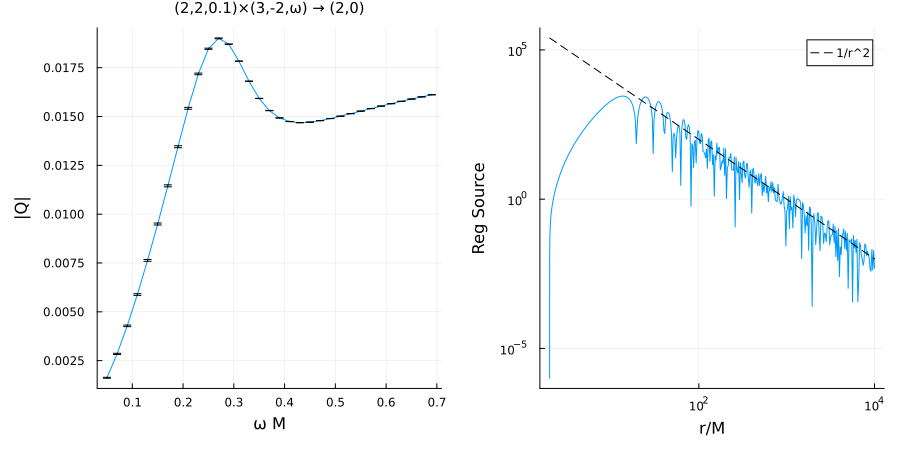

In [39]:
p1 = plot(ω_vals, q_vals; yerror = e_vals,seriestype = :path, label=nothing)
xlabel!(p1, "ω M")
ylabel!(p1, "|Q|")
title!(p1, "($l1,$m1,$ω1)×($l2,$m2,ω) → ($l,$(m1+m2))", titlefont=font(10))

# Bottom panel: something else (e.g. line)
p2 = plot(r_vals, src; xscale=:log10, yscale=:log10, label=nothing)
plot!(p2, r_vals, @. 1e6 * r_vals^(-2); label="1/r^2", linestyle=:dash, color=:black)
xlabel!(p2, "r/M")
ylabel!(p2, "Reg Source")

# 2x1 layout
plot(p1, p2; layout = (1, 2), size=(900, 450), bottom_margin = 6Plots.mm, left_margin   = 6Plots.mm, top_margin = 2Plots.mm, right_margin = 2Plots.mm)